1000 rows of the data:
     age     sex     bmi  children smoker     region      charges
0     19  female  27.900         0    yes  southwest  16884.92400
1     18    male  33.770         1     no  southeast   1725.55230
2     28    male  33.000         3     no  southeast   4449.46200
3     33    male  22.705         0     no  northwest  21984.47061
4     32    male  28.880         0     no  northwest   3866.85520
..   ...     ...     ...       ...    ...        ...          ...
995   39  female  23.275         3     no  northeast   7986.47525
996   39  female  34.100         3     no  southwest   7418.52200
997   63  female  36.850         0     no  southeast  13887.96850
998   33  female  36.290         3     no  northeast   6551.75010
999   36  female  26.885         0     no  northwest   5267.81815

[1000 rows x 7 columns]
------------------------------
Model Accuracy (R-Squared): 0.78 (1.0 is perfect)
Average Error (Root Mean Squared Error): $5796.28
-----------------------------

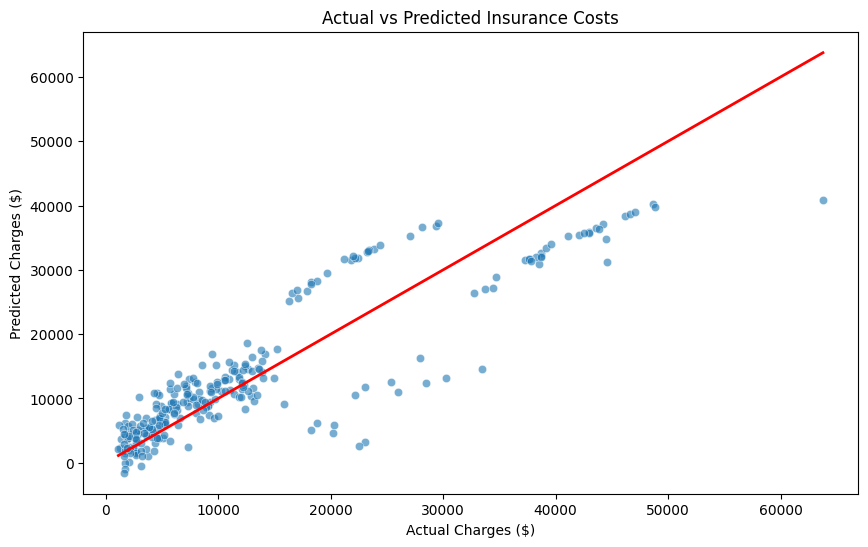

['linear.pkl ']

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("1000 rows of the data:")
print(df.head(1000))
print("-" * 30)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Model Accuracy (R-Squared): {r2:.2f} (1.0 is perfect)")
print(f"Average Error (Root Mean Squared Error): ${np.sqrt(mse):.2f}")

print("-" * 30)
print("Feature Importance (Weights):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Ideal line
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Costs')
plt.show()

import joblib

joblib.dump(model, 'linear.pkl ')